<a href="https://colab.research.google.com/github/jolineuichanco/DataAnalytics/blob/main/demos/Week07_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 7 demo**

In [ ]:
# first download the data
import pandas as pd

url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)

df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

## Use Sklearn to fit a logistic model

In [ ]:
from sklearn.linear_model import LogisticRegression

# our features are "gre", "gpa", "rank"
X = df[['gre', 'gpa', 'rank']]
# our response variable is "admit"
y = df['admit']

# create an instance of Logistic Regression
model_sklearn = LogisticRegression()
model_sklearn.fit(X, y)

print('Logistic Regression model trained successfully.')

In [ ]:
model_sklearn.coef_

In [ ]:
model_sklearn.intercept_

# Using Statsmodels to fit a Logistic Model


In [ ]:
import statsmodels.formula.api as smf

model_smf = smf.logit('admit ~ gre + gpa + rank', data=df)
result = model_smf.fit()

print(result.summary())

# Classification from the Logistic Model

We can turn the estimated probabilities from the logit models into predictions of the class label (i.e., `admit` or `not admit`). Let's use Sklearn's estimated model.

In [ ]:
# our features are "gre", "gpa", "rank"
X = df[['gre', 'gpa', 'rank']]
# our response variable is "admit"
y = df['admit']

# create an instance of Logistic Regression
model = LogisticRegression()
model.fit(X, y)

# Generate predictions on the test set
y_pred = model.predict(X)

display(y_pred)

In [ ]:
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
results_df.head()

Clearly there are some observations that are "mislabeled". We want to know the accuracy of the model by looking at how many are mislabeled.

In [ ]:
import seaborn as sns
sns.countplot(data=results_df.melt(), x='value', hue='variable', palette='viridis')
plt.title('Distribution of Actual vs. Predicted Admission Status')
plt.xlabel('Admission Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Admitted', 'Admitted'])
plt.legend(title='Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot()

## Computing the accuracy metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

TN, FP, FN, TP = cm.ravel()

# Calculate True Positive Rate (TPR) / Recall
tpr = TP / (TP + FN)

# Calculate False Positive Rate (FPR)
fpr = FP / (FP + TN)

print(f'True Positive Rate (TPR): {tpr:.4f}')
print(f'False Positive Rate (FPR): {fpr:.4f}')

# Calculate other accuracy metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')


### **In-Class Exercise: Titanic Predictions**

Build a model for predicting survival. Evaluate the accuracy of your model.

In [42]:
import pandas as pd

url = 'https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv'
titanic = pd.read_csv(url)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic.info()

In [ ]:
survival_counts = titanic['Survived'].value_counts()
print(survival_counts)

In [ ]:
survival_prop = titanic['Survived'].value_counts()/len(titanic)
print(survival_prop)

In [ ]:
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = titanic.corr(numeric_only=True)

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

In [43]:
import statsmodels.formula.api as smf

model = smf.logit('Survived ~ Pclass + Sex + Age + SibSp + Parch + Fare + Embarked', data=titanic)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.444061
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      703
Method:                           MLE   Df Model:                            8
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  0.3419
Time:                        20:28:11   Log-Likelihood:                -316.17
converged:                       True   LL-Null:                       -480.45
Covariance Type:            nonrobust   LLR p-value:                 3.392e-66
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.6374      0.635      8.884      0.000       4.394       6.881
Sex[T.male]      -2.

In [51]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

url = 'https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv'
titanic = pd.read_csv(url)

# Fill missing 'Age' values with the mean BEFORE one-hot encoding to avoid issues
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())

# Perform one-hot encoding for 'Sex' and 'Embarked'
titanic_encoded = pd.get_dummies(titanic, columns=['Sex', 'Embarked'], dtype=int)

# Select relevant features and target variable (update features to include new one-hot encoded columns)
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X_titanic = titanic_encoded[features]
y_titanic = titanic_encoded['Survived']

# Train the logistic regression model on the entire dataset
model_titanic = LogisticRegression(max_iter=1000)
model_titanic.fit(X_titanic, y_titanic)

# Make predictions on the entire dataset
y_pred_titanic = model_titanic.predict(X_titanic)

# Display the first few actual vs. predicted values
results_titanic_df = pd.DataFrame({'Actual': y_titanic, 'Predicted': y_pred_titanic})
display(results_titanic_df.head())

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


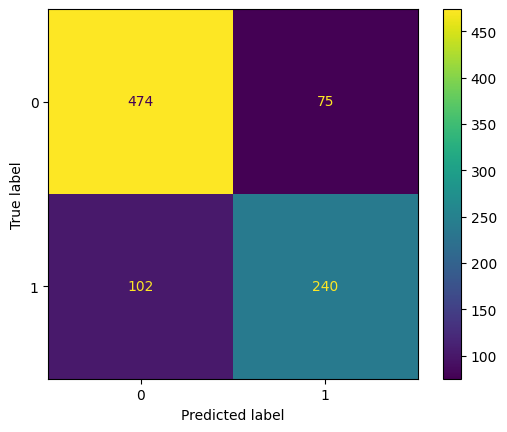

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_titanic, y_pred_titanic)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model_titanic.classes_)
disp.plot()

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

TN, FP, FN, TP = cm.ravel()

# Calculate True Positive Rate (TPR) / Recall
tpr = TP / (TP + FN)

# Calculate False Positive Rate (FPR)
fpr = FP / (FP + TN)

print(f'True Positive Rate (TPR): {tpr:.4f}')
print(f'False Positive Rate (FPR): {fpr:.4f}')

# Calculate other accuracy metrics
accuracy = accuracy_score(y_titanic, y_pred_titanic)
precision = precision_score(y_titanic, y_pred_titanic)
recall = recall_score(y_titanic, y_pred_titanic)
f1 = f1_score(y_titanic, y_pred_titanic)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

True Positive Rate (TPR): 0.7018
False Positive Rate (FPR): 0.1366
Accuracy: 0.8013
Precision: 0.7619
Recall: 0.7018
F1-Score: 0.7306


# Splitting Data into Test and Train Sets

In [ ]:
from sklearn.model_selection import train_test_split

url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)

# our features are "gre", "gpa", "rank"
X = df[['gre', 'gpa', 'rank']]
# our response variable is "admit"
y = df['admit']

In [ ]:
# split the data into training and testing (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

In [ ]:
# the observations chosen for training versus testing are truly random
X_test

Train the model on the train set. Evaluate the model on the test set.

In [ ]:
# train the model on the training set only
model = LogisticRegression()
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model_sklearn.predict(X_test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df.head()

In [ ]:
# we will use the accuracy metrics to make this evaluation

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

TN, FP, FN, TP = cm.ravel()

# Calculate True Positive Rate (TPR) / Recall
tpr = TP / (TP + FN)

# Calculate False Positive Rate (FPR)
fpr = FP / (FP + TN)

print(f'True Positive Rate (TPR): {tpr:.4f}')
print(f'False Positive Rate (FPR): {fpr:.4f}')

# Calculate other accuracy metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

True Positive Rate (TPR): 0.2500
False Positive Rate (FPR): 0.0469
Accuracy: 0.7000
Precision: 0.7500
Recall: 0.2500
F1-Score: 0.3750


### **In-Class Exercise: Titanic Predictions Again**

  

1.   Split the titanic data between training and testing.
2.   Build your model again, but now with just the training dataset.
3.   Evaluate it on the test set and see the accuracy.

In [70]:
import pandas as pd

url = 'https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv'
df_new = pd.read_csv(url)

df_new.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Load the dataframe again for this exercise block to ensure a clean start if needed.
# In the current notebook state, df_new is already loaded in cell O3cyZbnMNc2v.
# If this cell were to be run independently, df_new might not be defined.
# For consistency with the exercise, let's assume df_new is available from the previous cell.


# our features are "Age", "SibSp", "Parch"
X = df_new[['SibSp', 'Parch', 'Fare']]
# our response variable is "Survived"
y = df_new['Survived']

# split the data into training and testing (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25) # Added random_state for reproducibility

# train the model on the training set only
model = LogisticRegression() # Increased max_iter for convergence if needed
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test) # Changed from model_sklearn to model as per exercise

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df.head()

,Actual,Predicted
603,0,0
873,0,0
713,0,0
517,0,0
464,0,0


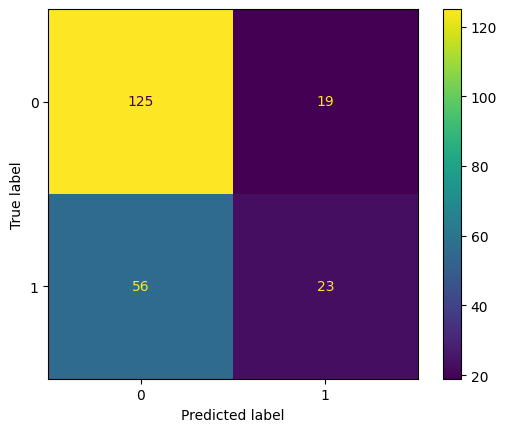

In [81]:
# we will use the accuracy metrics to make this evaluation

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot()

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

TN, FP, FN, TP = cm.ravel()

# Calculate True Positive Rate (TPR) / Recall
tpr = TP / (TP + FN)

# Calculate False Positive Rate (FPR)
fpr = FP / (FP + TN)

print(f'True Positive Rate (TPR): {tpr:.4f}')
print(f'False Positive Rate (FPR): {fpr:.4f}')

# Calculate other accuracy metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

True Positive Rate (TPR): 0.2911
False Positive Rate (FPR): 0.1319
Accuracy: 0.6637
Precision: 0.5476
Recall: 0.2911
F1-Score: 0.3802
